### Monstrinho 3.5 - A curva de aprendizado

#### Enunciado 

Objetivo: Implemente o registro da curva de aprendizado tanto dos dados de treino
quanto de validação no código de redes neurais feito em Python puro nesta disciplina.
Além de implementar, treine um modelo de rede neural em um conjunto de dados qualquer
e mostre e interprete o gráfico das curvas de aprendizado.

Comentário: observe que o enunciado diz claramente que é para realizar a tarefa na
rede neural feita em Python puro nos vídeos da disciplina. Se você está usando o PyTorch,
numpy, tensorflow, keras, lightning ou qualquer outra biblioteca pronta, você está no
caminho errado!

### Introdução

A curva de aprendizado pode ser usada para analisar melhor como está o desempenho do seu modelo. Basicamente eu fiz esse monstrinho após já ter feito métodos para registrar esse gráfico em algumas feras, portanto, foi simples implementar esse código. 

Criei duas listas que registram a `loss` de treino e de validação e a partir delas plotei os gráficos usando o `matplotlib`.

### Importando bibliotecas

In [384]:
from classes import Valor, Neuronio, Camada, MLP
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

### Definindo dados de treino e de validação

Todos esses dados foram criados pelo modelo de linguagem ChatGPT da OpenAi após um pedido que ele gerasse dados que tendiam a dar overfitting. Isso foi necessário pois não consegui encontrar um dataset que tendia a overfitar para mostrar o quão útil pode ser analisar uma curva de aprendizado.

In [385]:
x = [[0.0, 0.5263, 1.0526, 1.5789, 2.1053, 2.6316, 3.1579, 3.6842, 4.2105, 4.7368, 
     5.2632, 5.7895, 6.3158, 6.8421, 7.3684, 7.8947, 8.4211, 8.9474, 9.4737, 10.0]]

y_true = [ 0.1497, 0.4004, 0.8584, 0.9438, 0.8592, 0.7091, 0.2105, -0.3919, 
           -0.5634, -0.9199, -0.8300, -0.6914, -0.1152, 0.2214, 0.6017, 
            0.9426, 0.5950, 0.6400, 0.0513, -0.3575]

x_val = [[0.5, 0.9737, 1.4474, 1.9211, 2.3947, 2.8684, 3.3421, 3.8158, 4.2895, 4.7632, 
         5.2368, 5.7105, 6.1842, 6.6579, 7.1316, 7.6053, 8.0789, 8.5526, 9.0263, 9.5]]

y_val = [0.4794, 0.8263, 0.9923, 0.9392, 0.6816, 0.2787, -0.1978, -0.6246, 
         -0.9092, -0.9982, -0.8822, -0.5828, -0.1411, 0.3302, 0.7238, 
          0.9636, 0.9870, 0.7821, 0.3777, -0.0752]

### Definindo a MLP

In [386]:
NUM_DADOS_DE_ENTRADA = 20
NUM_DADOS_DE_SAIDA = 1    
CAMADAS_OCULTAS = [3, 2]  

arquitetura_da_rede = CAMADAS_OCULTAS + [NUM_DADOS_DE_SAIDA]

minha_mlp = MLP(NUM_DADOS_DE_ENTRADA, arquitetura_da_rede)

### Treinando a rede neural

In [387]:
NUM_EPOCAS = 600
TAXA_DE_APRENDIZADO = 0.05

# Listas para plot
x_plot = []
y_treino_plot = []
y_val_plot = []

for epoca in range(NUM_EPOCAS):
    
    # forward pass
    y_pred = []
    for exemplo in x:
        previsao = minha_mlp(exemplo)
        y_pred.append(previsao)

    # loss
    erros = []
    for yt, yp in zip(y_true, y_pred):
        residuo = yp - yt
        erro_quadratico = residuo ** 2
        erros.append(erro_quadratico)        
    loss = sum(erros)

    # zero grad
    for p in minha_mlp.parametros():
        p.grad = 0

    # backpropagation
    loss.propagar_tudo()

    # atualiza parâmetros
    for p in minha_mlp.parametros():
        p.data = p.data - p.grad * TAXA_DE_APRENDIZADO
        
    # validação
    y_val_pred = [minha_mlp(exemplo) for exemplo in x_val] # Fera 4.3
        
    erros_val = [(yp - yt)**2 for yp, yt in zip(y_val_pred, y_val)]
    loss_val = sum(erros_val)
    
    # mostra resultado (opcional)
    print(f"Época {epoca + 1} — Perda Treino: {loss.data} | Perda Validação: {loss_val.data}")
    
    if epoca != 0:
        x_plot.append(epoca)
        y_treino_plot.append(loss.data)
        y_val_plot.append(loss_val.data)

Época 1 — Perda Treino: 0.19787301822877043 | Perda Validação: 0.012451867629797048
Época 2 — Perda Treino: 0.194912050635435 | Perda Validação: 0.011719679824714212
Época 3 — Perda Treino: 0.1919795289921933 | Perda Validação: 0.011011294675989517
Época 4 — Perda Treino: 0.18907601063954232 | Perda Validação: 0.010326718215461541
Época 5 — Perda Treino: 0.18620201809963224 | Perda Validação: 0.009665932795135702
Época 6 — Perda Treino: 0.18335803913896787 | Perda Validação: 0.009028897634958748
Época 7 — Perda Treino: 0.18054452689278572 | Perda Validação: 0.00841554941302157
Época 8 — Perda Treino: 0.17776190005207324 | Perda Validação: 0.007825802895686027
Época 9 — Perda Treino: 0.17501054311351633 | Perda Validação: 0.0072595516048758815
Época 10 — Perda Treino: 0.1722908066920106 | Perda Validação: 0.0067166685195551275
Época 11 — Perda Treino: 0.1696030078947832 | Perda Validação: 0.006197006808244789
Época 12 — Perda Treino: 0.16694743075562612 | Perda Validação: 0.005700400589

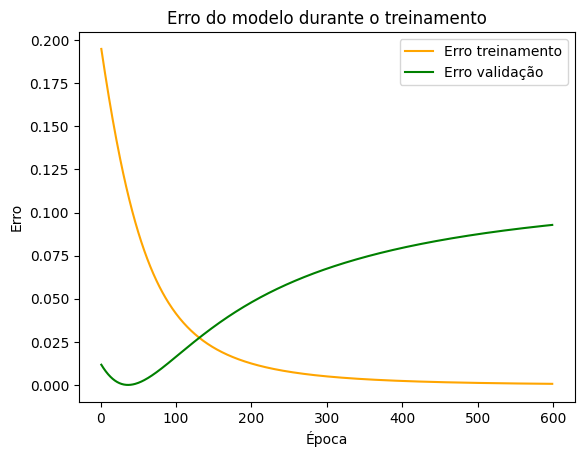

In [388]:
plt.plot(x_plot, y_treino_plot, color= "orange", label= "Erro treinamento")
plt.plot(x_plot, y_val_plot, color= "green", label= "Erro validação")
plt.title("Erro do modelo durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.legend()

### Conclusão

Acrescentar o registro da curva de aprendiado é de grande utilidade para analisar como está a sua rede neural, se ela está diminuindo o erro corretamente. Observar comportamentos da curva em determinados momentos do treinamento pode ser crucial para mostrar se talvez pode ser interessante implementar uma estratégia para, por exemplo, evitar o overfitting da rede neural. Além disso, é conveniente utilizar esse gráfico para entender melhor o seu gráfico.

### Referências

1. Cassar, Daniel R. Material didático redes neurais do ano de 2025.

2. https://chatgpt.com/share/68464f3c-01f4-800b-80ff-d84d0672f343